In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 4000
Columns: 28


In [4]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [6]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing

,Missing Values,Percentage
Farm_ID,0,0.0
State,0,0.0
District,0,0.0
Crop,0,0.0
Season,0,0.0
Farm_Area_Hectares,0,0.0
Rainfall_mm,48,1.2
Avg_Temperature_C,0,0.0
Humidity_pct,0,0.0
Sunlight_Hours_Day,0,0.0


In [8]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (4000, 28)


In [9]:
print("Seasons:")
print(df['Season'].value_counts())

print("\nCrops:")
print(df['Crop'].value_counts())

print("\nIrrigation Methods:")
print(df['Irrigation_Method'].value_counts())

Seasons:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Crops:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Irrigation Methods:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


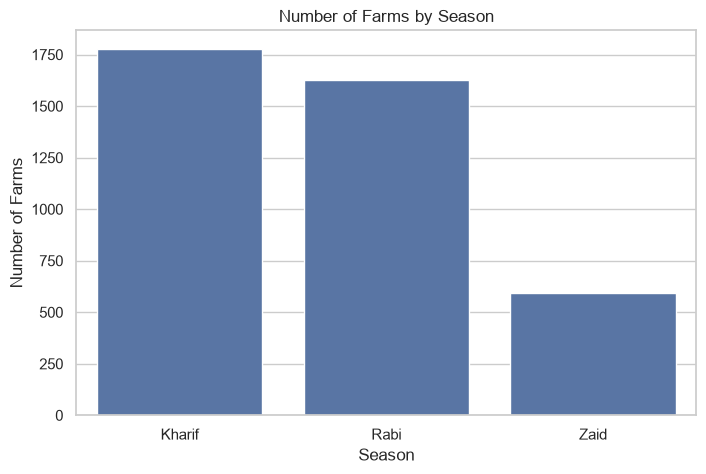

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Season')

plt.title("Number of Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.show()

Season
Kharif    5.64
Rabi      5.08
Zaid      4.67
Name: Yield_Tonnes_Ha, dtype: float64


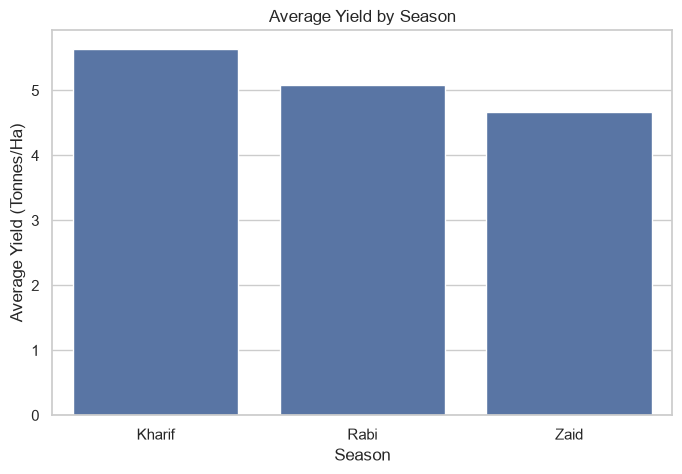

In [11]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

print(season_yield.round(2))

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_yield.index,
    y=season_yield.values
)

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.show()

Season
Kharif    46.31
Rabi      41.49
Zaid      38.89
Name: Production_Tonnes, dtype: float64


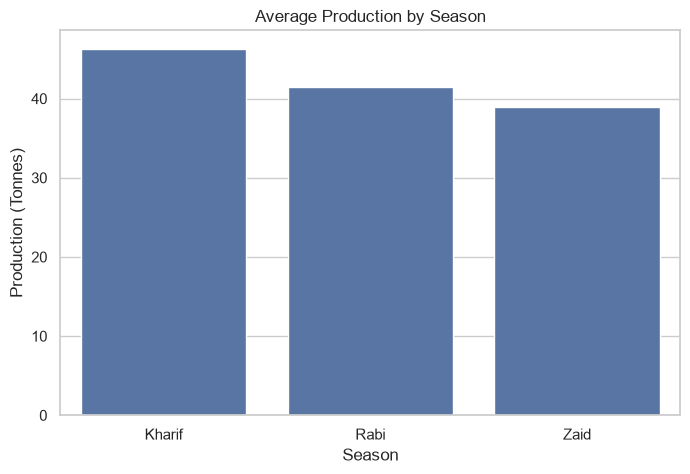

In [12]:
season_production = df.groupby('Season')['Production_Tonnes'].mean().sort_values(ascending=False)

print(season_production.round(2))

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_production.index,
    y=season_production.values
)

plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Production (Tonnes)")
plt.show()

        Revenue_INR  Total_Cost_INR  Profit_INR
Season                                         
Kharif    710719.06       531804.41   178914.65
Rabi      601526.05       513836.58    87689.47
Zaid      519171.90       543976.73   -24804.82


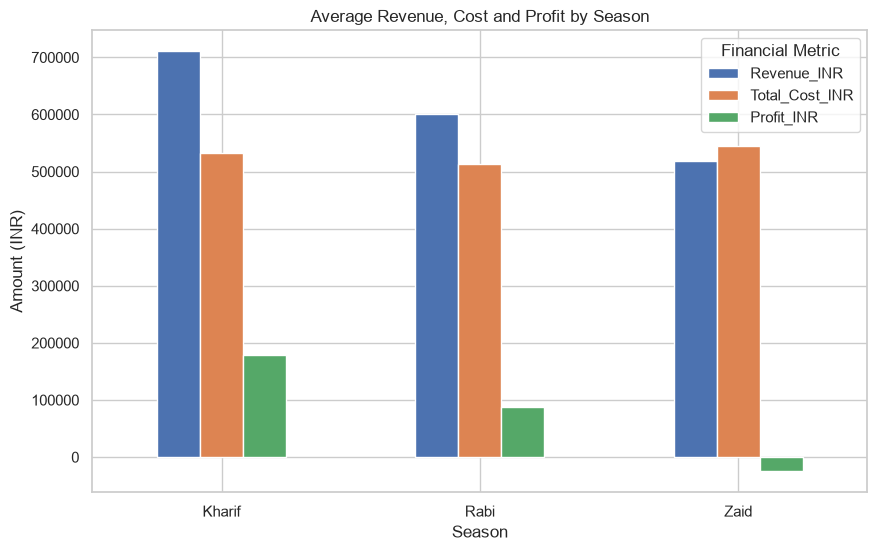

In [13]:
financial = df.groupby('Season')[
    ['Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
].mean()

print(financial.round(2))

financial.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Average Revenue, Cost and Profit by Season")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=0)
plt.legend(title="Financial Metric")
plt.show()

Season
Kharif    852.08
Rabi      436.00
Zaid      299.42
Name: Rainfall_mm, dtype: float64


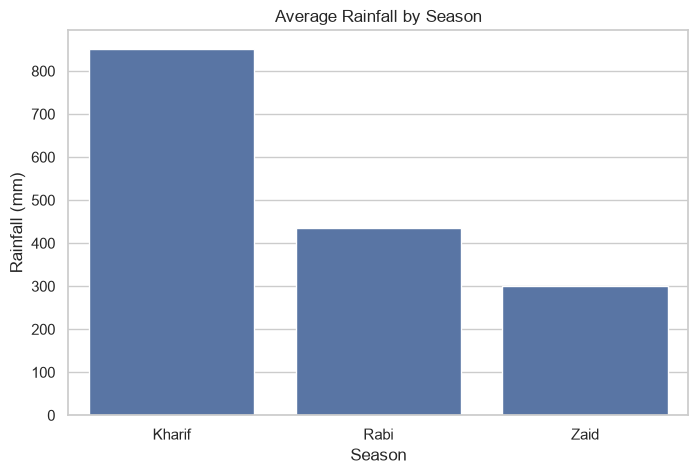

In [14]:
rainfall = df.groupby('Season')['Rainfall_mm'].mean().sort_values(ascending=False)

print(rainfall.round(2))

plt.figure(figsize=(8,5))

sns.barplot(
    x=rainfall.index,
    y=rainfall.values
)

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")
plt.show()

Season
Kharif    28.45
Rabi      23.49
Zaid      31.04
Name: Avg_Temperature_C, dtype: float64


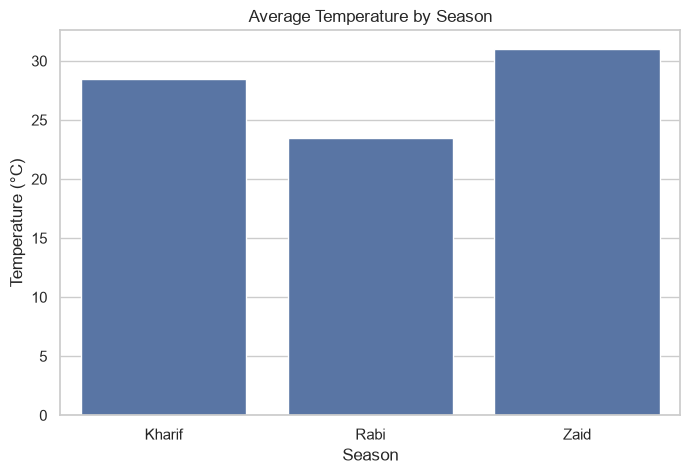

In [15]:
temperature = df.groupby('Season')['Avg_Temperature_C'].mean()

print(temperature.round(2))

plt.figure(figsize=(8,5))

sns.barplot(
    x=temperature.index,
    y=temperature.values
)

plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")
plt.show()

Season
Zaid      6419.89
Kharif    6102.20
Rabi      5846.99
Name: Water_Used_m3, dtype: float64


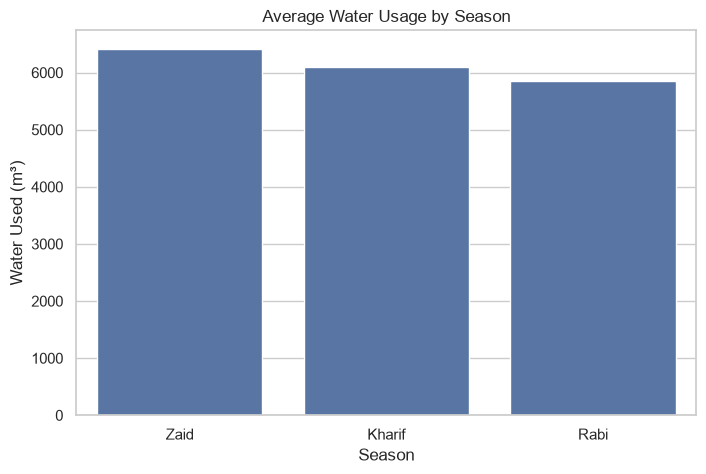

In [16]:
water = df.groupby('Season')['Water_Used_m3'].mean().sort_values(ascending=False)

print(water.round(2))

plt.figure(figsize=(8,5))

sns.barplot(
    x=water.index,
    y=water.values
)

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.show()

Season
Kharif    5.89
Rabi      5.19
Zaid      4.41
Name: Water_Efficiency_t_per_1000m3, dtype: float64


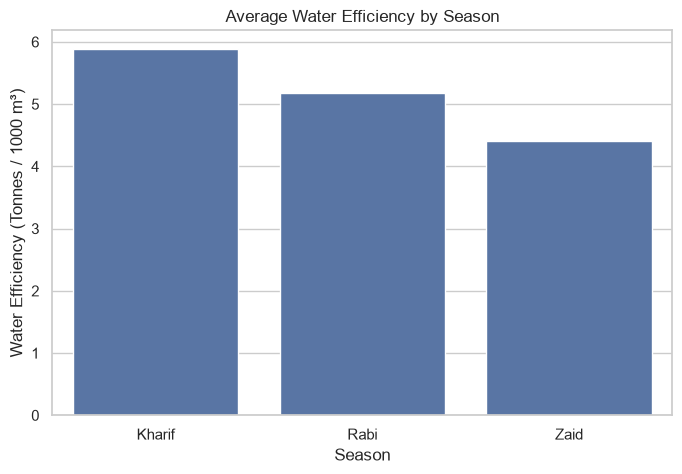

In [17]:
efficiency = df.groupby('Season')[
    'Water_Efficiency_t_per_1000m3'
].mean().sort_values(ascending=False)

print(efficiency.round(2))

plt.figure(figsize=(8,5))

sns.barplot(
    x=efficiency.index,
    y=efficiency.values
)

plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency (Tonnes / 1000 m³)")
plt.show()

Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64


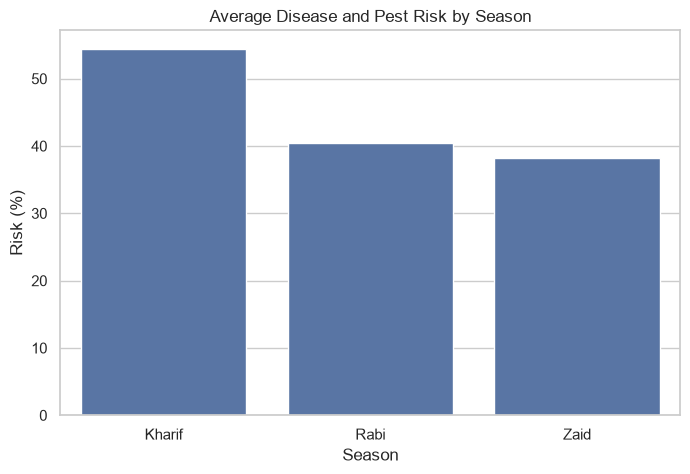

In [18]:
risk = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().sort_values(ascending=False)

print(risk.round(2))

plt.figure(figsize=(8,5))

sns.barplot(
    x=risk.index,
    y=risk.values
)

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.show()

Season     Kharif   Rabi   Zaid
Crop                           
Chilli       1.73   1.46   1.18
Cotton       1.37   1.19   0.95
Groundnut    1.48   1.22   1.04
Maize        2.97   2.61   2.30
Pulses       1.04   0.87   0.65
Rice         2.71   2.33   1.90
Sugarcane   53.46  43.94  38.42
Wheat        2.26   2.06   1.75


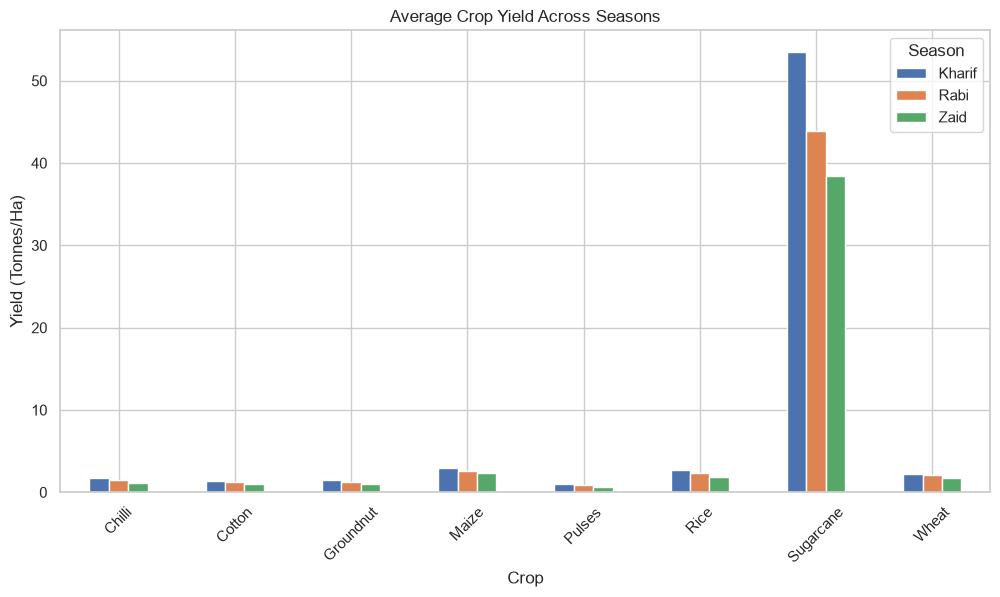

In [19]:
crop_season_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

print(crop_season_yield.round(2))

crop_season_yield.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.legend(title="Season")
plt.show()

Season         Kharif       Rabi       Zaid
Crop                                       
Chilli      954380.42  638572.50  448659.09
Cotton      216999.55  107343.59  -53925.34
Groundnut   108265.44   10416.54  -68872.50
Maize       -39332.67  -89133.40 -194049.17
Pulses       43338.90  -14309.14 -139227.81
Rice        -64903.40  -98427.87 -227239.34
Sugarcane  1000790.81  731612.86  583635.80
Wheat      -105871.87 -119954.57 -193208.95


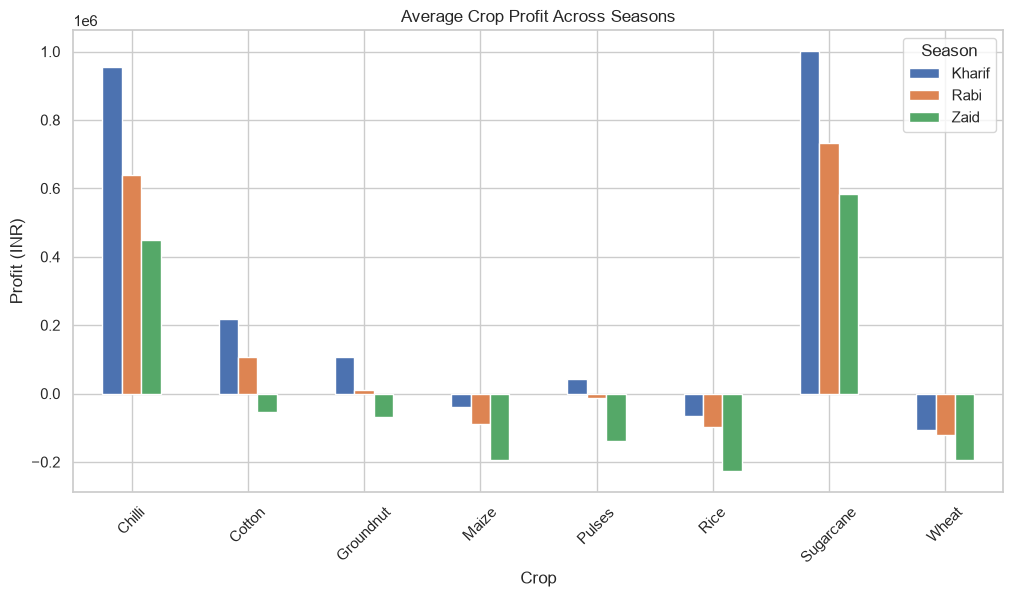

In [20]:
crop_season_profit = df.pivot_table(
    values='Profit_INR',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

print(crop_season_profit.round(2))

crop_season_profit.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Average Crop Profit Across Seasons")
plt.xlabel("Crop")
plt.ylabel("Profit (INR)")
plt.xticks(rotation=45)
plt.legend(title="Season")
plt.show()

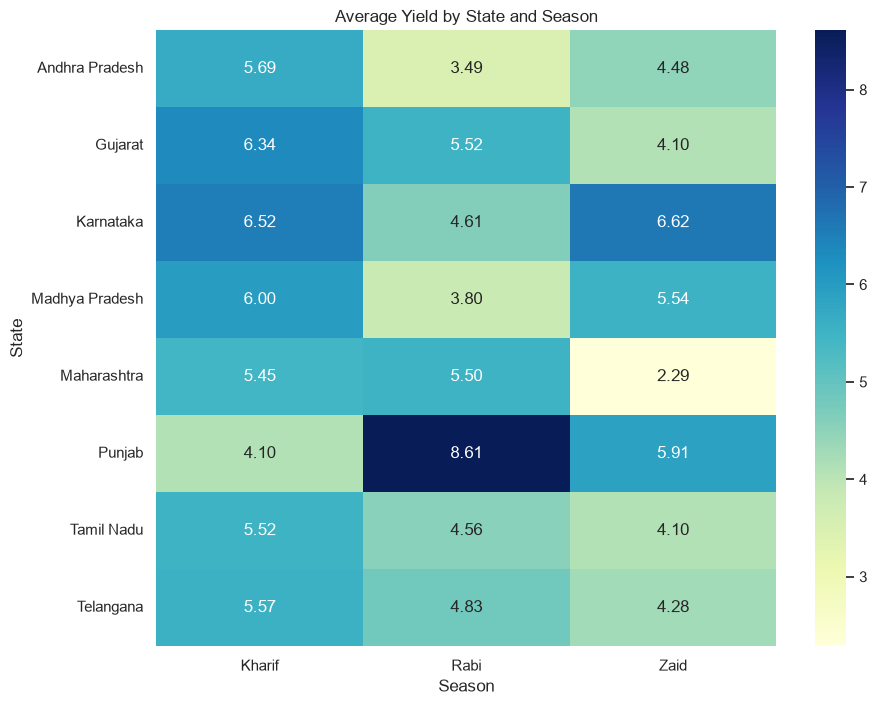

In [21]:
state_season_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='State',
    columns='Season',
    aggfunc='mean'
)

plt.figure(figsize=(10,8))

sns.heatmap(
    state_season_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.show()

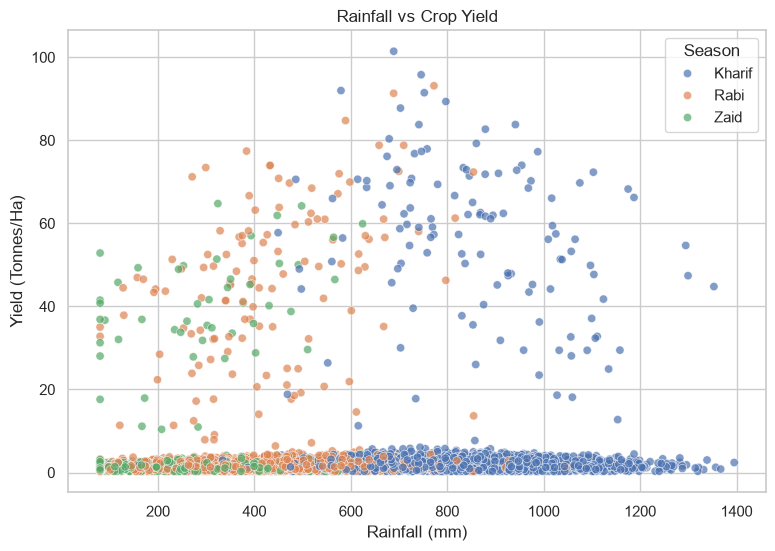

In [22]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season',
    alpha=0.7
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

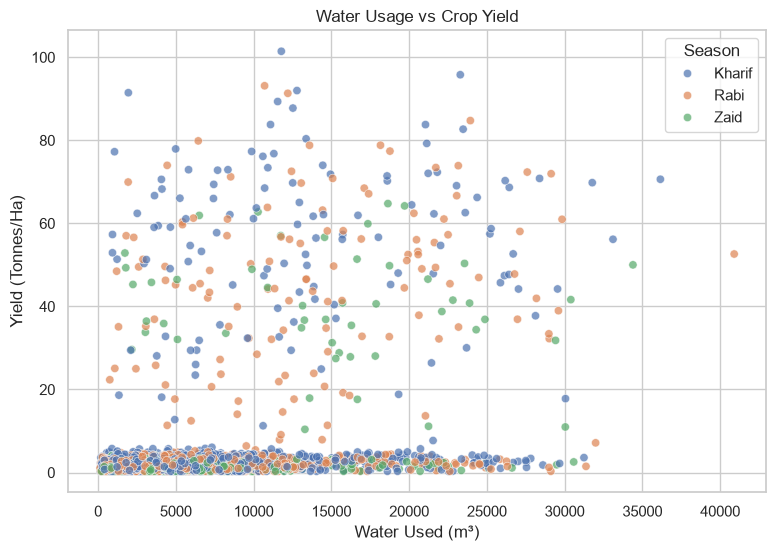

In [23]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha',
    hue='Season',
    alpha=0.7
)

plt.title("Water Usage vs Crop Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

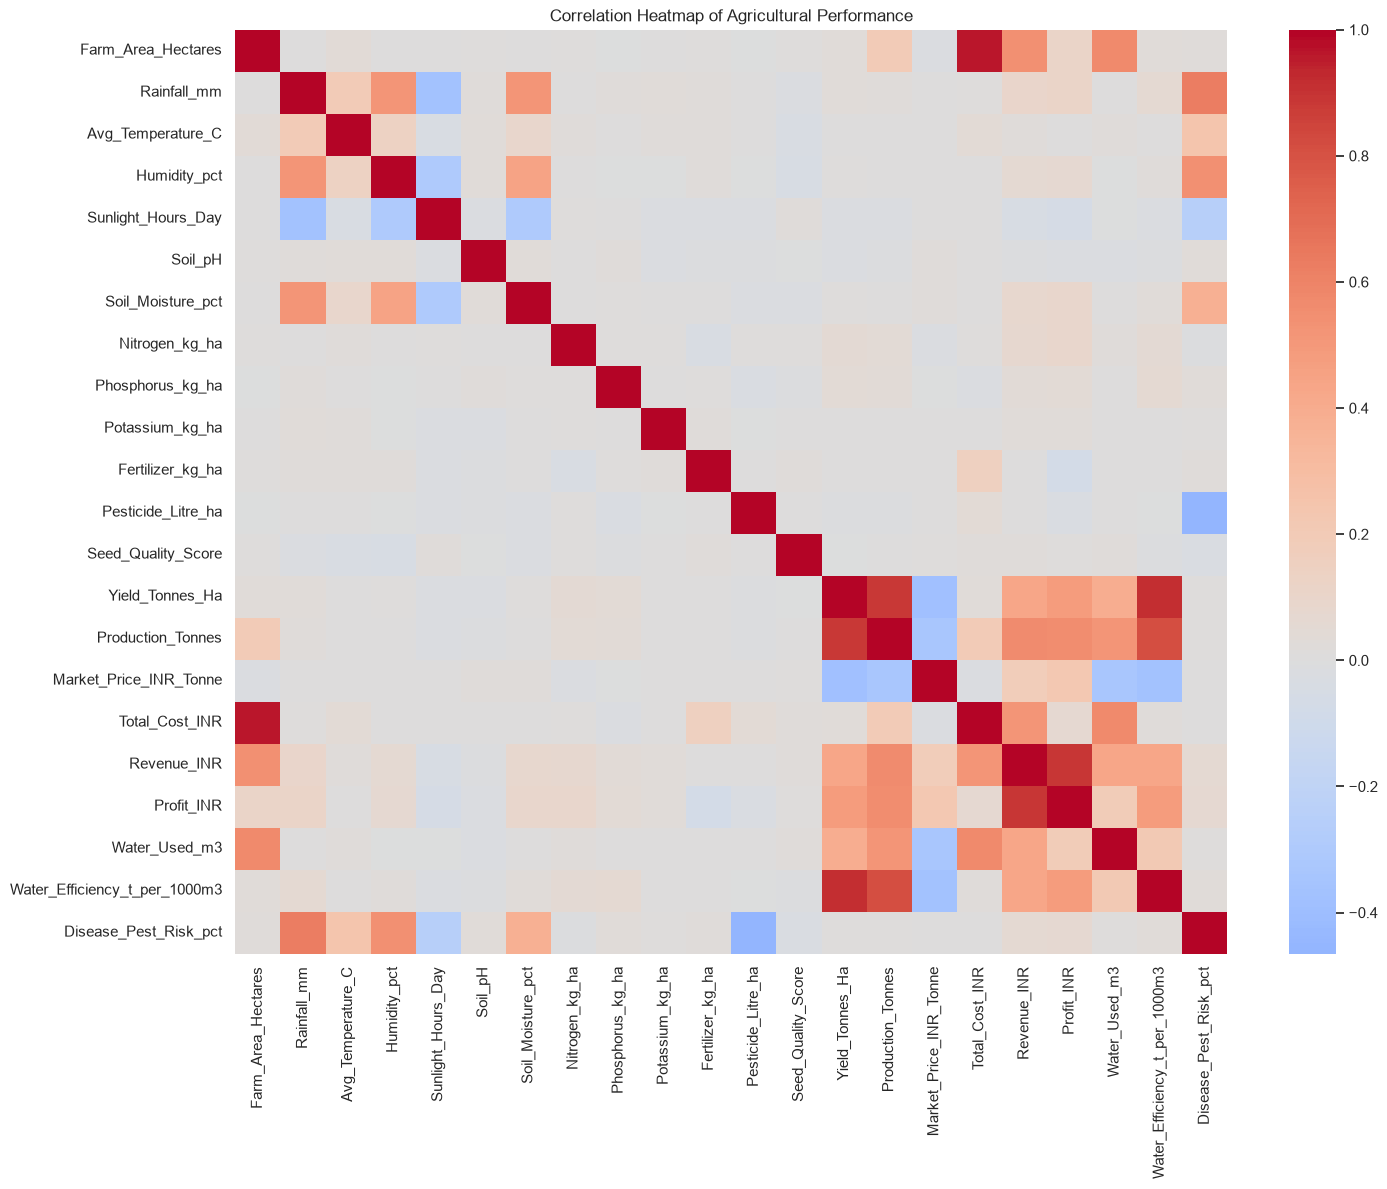

In [24]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap of Agricultural Performance")
plt.show()

In [25]:
seasonal_summary = df.groupby('Season').agg(
    Farms=('Season', 'count'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Production=('Production_Tonnes', 'mean'),
    Avg_Rainfall=('Rainfall_mm', 'mean'),
    Avg_Temperature=('Avg_Temperature_C', 'mean'),
    Avg_Water=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Cost=('Total_Cost_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Risk=('Disease_Pest_Risk_pct', 'mean')
).round(2)

seasonal_summary

,Farms,Avg_Yield,Avg_Production,Avg_Rainfall,Avg_Temperature,Avg_Water,Avg_Water_Efficiency,Avg_Revenue,Avg_Cost,Avg_Profit,Avg_Risk
Season,,,,,,,,,,,
Kharif,1779,5.64,46.31,852.08,28.45,6102.20,5.89,710719.06,531804.41,178914.65,54.47
Rabi,1627,5.08,41.49,436.00,23.49,5846.99,5.19,601526.05,513836.58,87689.47,40.48
Zaid,594,4.67,38.89,299.42,31.04,6419.89,4.41,519171.90,543976.73,-24804.82,38.22


In [26]:
best_yield = seasonal_summary['Avg_Yield'].idxmax()
best_profit = seasonal_summary['Avg_Profit'].idxmax()
best_efficiency = seasonal_summary['Avg_Water_Efficiency'].idxmax()
highest_risk = seasonal_summary['Avg_Risk'].idxmax()

print("========== FINAL INSIGHTS ==========\n")

print(f"1. Highest average yield: {best_yield}")
print(f"2. Highest average profit: {best_profit}")
print(f"3. Highest water efficiency: {best_efficiency}")
print(f"4. Highest disease/pest risk: {highest_risk}")

print("\nKey Observations:")
print("- Kharif shows the highest average yield.")
print("- Kharif also gives the highest average revenue and profit.")
print("- Zaid has the lowest average yield and negative average profit.")
print("- Zaid uses the highest average amount of water.")
print("- Kharif has the highest water efficiency.")
print("- Kharif has the highest disease and pest risk.")

========== FINAL INSIGHTS ==========

1. Highest average yield: Kharif
2. Highest average profit: Kharif
3. Highest water efficiency: Kharif
4. Highest disease/pest risk: Kharif

Key Observations:
- Kharif shows the highest average yield.
- Kharif also gives the highest average revenue and profit.
- Zaid has the lowest average yield and negative average profit.
- Zaid uses the highest average amount of water.
- Kharif has the highest water efficiency.
- Kharif has the highest disease and pest risk.
